<a href="https://colab.research.google.com/github/kirtiver22/AIRBNB-EDA-PROJECT/blob/main/airbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT LIBRARIES


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATASET LAODING

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
path ='/content/drive/MyDrive/Colab Notebooks/AB_NYC_2019.csv/AB_NYC_2019.csv'

Dataset first view

In [ ]:
airbnb = pd.read_csv(path)

In [ ]:
airbnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


Dataset Rows & Columns count

In [ ]:
airbnb.shape

(48895, 16)

Dataset information

In [ ]:
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

Duplicate values

In [ ]:
airbnb.duplicated().sum()

np.int64(0)

Missing values

In [ ]:
airbnb.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
missing_count = airbnb.isnull().sum().sort_values(ascending = False)
print(missing_count)
print('/n')

last_review                       10052
reviews_per_month                 10052
host_name                            21
name                                 16
neighbourhood_group                   0
neighbourhood                         0
id                                    0
host_id                               0
longitude                             0
latitude                              0
room_type                             0
price                                 0
number_of_reviews                     0
minimum_nights                        0
calculated_host_listings_count        0
availability_365                      0
dtype: int64
/n


understanding variables

In [ ]:
#dataset columns
airbnb.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

check unique values for each avriable

In [ ]:
# Check Unique Values for each variable.

unq_val = airbnb.apply(lambda col: col.unique())

unq_val

,0
id,"[2539, 2595, 3647, 3831, 5022, 5099, 5121, 517..."
name,"[Clean & quiet apt home by the park, Skylit Mi..."
host_id,"[2787, 2845, 4632, 4869, 7192, 7322, 7356, 896..."
host_name,"[John, Jennifer, Elisabeth, LisaRoxanne, Laura..."
neighbourhood_group,"[Brooklyn, Manhattan, Queens, Staten Island, B..."
neighbourhood,"[Kensington, Midtown, Harlem, Clinton Hill, Ea..."
latitude,"[40.64749, 40.75362, 40.80902, 40.68514, 40.79..."
longitude,"[-73.97237, -73.98377, -73.9419, -73.95976, -7..."
room_type,"[Private room, Entire home/apt, Shared room]"
price,"[149, 225, 150, 89, 80, 200, 60, 79, 135, 85, ..."


####Data wrangling

In [ ]:
#missing values count
missing_count[:4]

,0
last_review,10052
reviews_per_month,10052
host_name,21
name,16


In [ ]:
#percentage of null values in last_review, last_review_per_month, name
columns = ['last_review', 'reviews_per_month', 'name','host_name']

null_percentage = (airbnb[columns].isnull().sum() / len(airbnb)) * 100
null_percentage

,0
last_review,20.558339
reviews_per_month,20.558339
name,0.032723
host_name,0.042949


In [ ]:
# Handling missing values using direct assignment
airbnb['last_review'] = airbnb['last_review'].fillna('Not Reviewed')
airbnb['reviews_per_month'] = airbnb['reviews_per_month'].fillna(0)
airbnb['host_name'] = airbnb['host_name'].fillna('Unknown')
airbnb['name'] = airbnb['name'].fillna('No Name')

In [ ]:
airbnb.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
# Filtering out listings with price >= 500 to focus on the mainstream market, as identified in chart-10
airbnb = airbnb[airbnb['price'] < 500]
print(f'Number of listings after price filtering: {len(airbnb)}')


Number of listings after price filtering: 47660


####chart - 1

['Private room' 'Entire home/apt' 'Shared room']


room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64




<Axes: xlabel='room_type'>

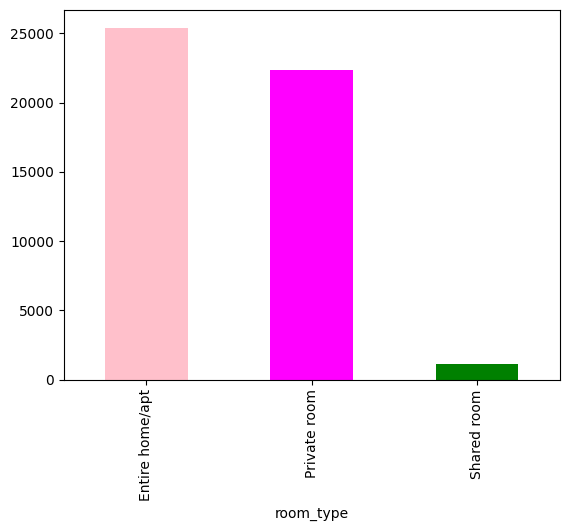

In [ ]:
# Chart - 1 visualization code
print(airbnb.room_type.unique())
print('\n')

room_typ=airbnb.room_type.value_counts()
print(room_typ)
print('\n')

airbnb['room_type'].value_counts().plot(kind='bar',color=['pink','magenta','green'])


Finding: "Entire home/apt" is the most preferred room type, followed by "Private room," while "Shared room" is the least preferred.

Insight: Hosts offering shared rooms need significant improvements in their offerings to boost demand. The market strongly favors full autonomy.

Business Action: Shared room hosts should invest in amenities, cleanliness, and unique features to compete.


####CHART - 2 Price vs. Availability


<Axes: xlabel='availability_365', ylabel='price'>

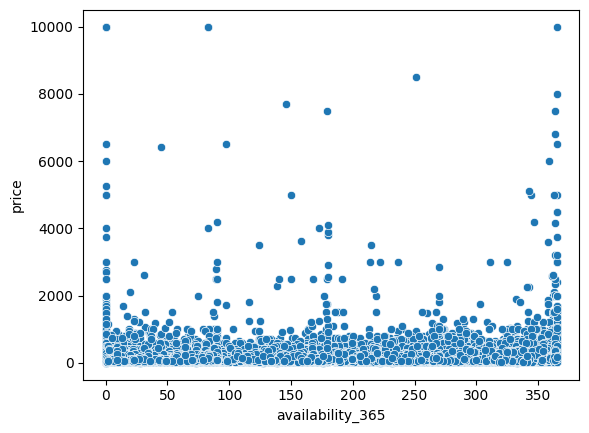

In [ ]:
# Chart - 2 visualization code
sns.scatterplot(y=airbnb['price'],x=airbnb['availability_365'])

Finding: Scatter plot showing relationship between room prices and 365-day availability.

Insight: More affordable rooms tend to have higher availability, indicating consistent demand at lower price points.

Business Action: Price rooms competitively—rooms under $500/night attract more bookings.

####CHART-3 Geographic Distribution by Neighbourhood

['Brooklyn' 'Manhattan' 'Queens' 'Staten Island' 'Bronx']




<Axes: xlabel='latitude', ylabel='longitude'>

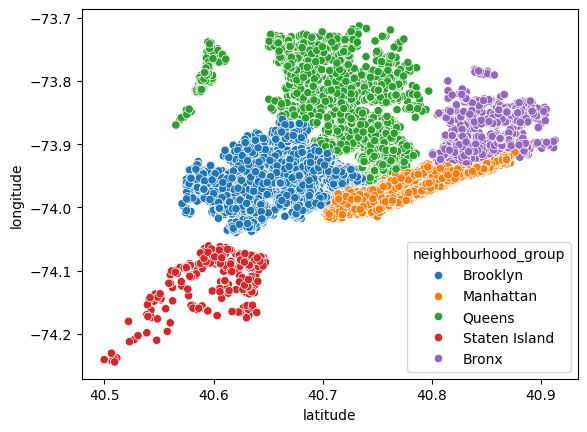

In [ ]:
# Chart - 3 visualization code
neigh_unq=airbnb.neighbourhood_group.unique()
print(neigh_unq)
print('\n')

sns.scatterplot(x=airbnb.latitude,y=airbnb.longitude,hue=airbnb.neighbourhood_group)

Finding: Spatial distribution shows concentration of listings in Manhattan and Brooklyn.

Insight: These two boroughs dominate the market, indicating higher customer interest and business opportunities.

Business Action: Expand presence in Manhattan/Brooklyn; consider diversifying into underserved areas (Queens, Bronx, Staten Island).

####CHART-4 Max Price by Neighbourhood & Room Type

In [ ]:
# Chart - 4 visualization code
room_price_area_wise = airbnb.groupby(['neighbourhood_group','room_type'])['price'].max().reset_index()
room_price_area_wise.sort_values(by='price', ascending=False).head(10)

,neighbourhood_group,room_type,price
3,Brooklyn,Entire home/apt,10000
6,Manhattan,Entire home/apt,10000
10,Queens,Private room,10000
7,Manhattan,Private room,9999
4,Brooklyn,Private room,7500
12,Staten Island,Entire home/apt,5000
9,Queens,Entire home/apt,2600
1,Bronx,Private room,2500
11,Queens,Shared room,1800
0,Bronx,Entire home/apt,1000


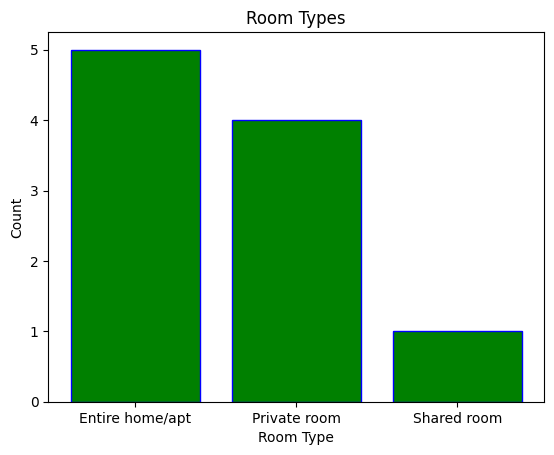

In [ ]:
neighbourhood_group = ['Brooklyn', 'Manhattan', 'Queens', 'Manhattan', 'Brooklyn', 'Staten Island', 'Queens', 'Bronx', 'Queens', 'Bronx']
room_type = ['Entire home/apt', 'Entire home/apt', 'Private room', 'Private room', 'Private room', 'Entire home/apt', 'Entire home/apt', 'Private room', 'Shared room', 'Entire home/apt']

room_dict = {} #Create a dictionary named room_dict to store the count of each room type. Loop through the room_type list and increase the count of the room type in the dictionary if it already exists. If not, add the room type as a key with the count as 1.

for i in room_type:
    room_dict[i] = room_dict.get(i, 0) + 1

plt.bar(room_dict.keys(), room_dict.values(), color='green', edgecolor='blue') #Plot a bar graph using the plt.bar function. The x-axis will be the room types which are the keys of the room_dict dictionary and the y-axis will be the count of each room type which are the values of the room_dict dictionary.
plt.title('Room Types')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()


Finding: Brooklyn and Manhattan have highest prices for entire homes; Manhattan dominates for premium rooms.

Insight: Entire homes command premium pricing in major boroughs; shared/private rooms have lower ceiling prices.

Business Action: Differentiate pricing strategy by borough and room type.

####CHART- 5 Price vs. Reviews


In [ ]:
# Chart - 5 visualization code
area_reviews = airbnb.groupby(['neighbourhood_group'])['number_of_reviews'].max().reset_index()
area_reviews

,neighbourhood_group,number_of_reviews
0,Bronx,321
1,Brooklyn,488
2,Manhattan,607
3,Queens,629
4,Staten Island,333


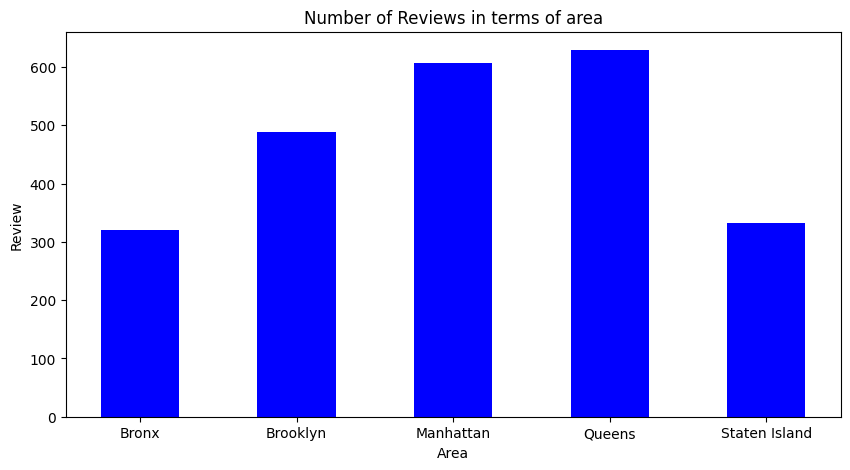

In [ ]:
area = area_reviews['neighbourhood_group']
review = area_reviews['number_of_reviews']
fig = plt.figure(figsize =(10,5))

plt.bar(area, review, color ="blue", width =0.5)
plt.xlabel('Area')
plt.ylabel('Review')
plt.title("Number of Reviews in terms of area")
plt.show()

In [ ]:
price_area = airbnb.groupby(['price'])['number_of_reviews'].max().reset_index()
price_area.head(10)

,price,number_of_reviews
0,0,95
1,10,93
2,11,113
3,12,8
4,13,9
5,15,19
6,16,43
7,18,1
8,19,76
9,20,116


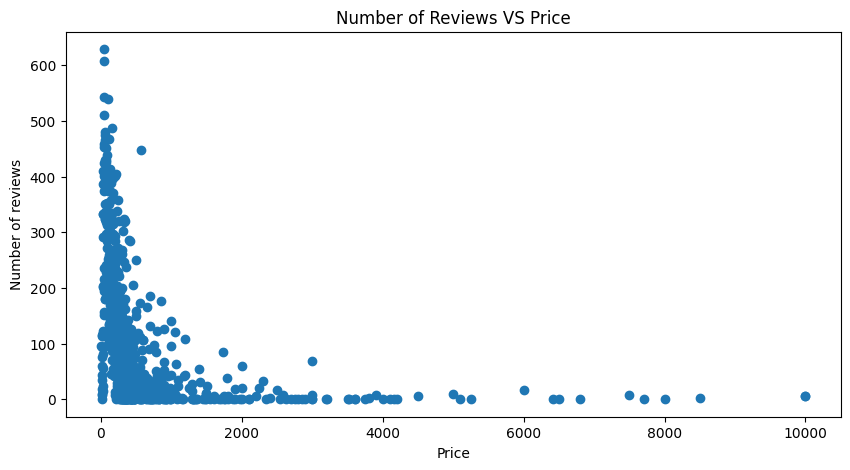

In [ ]:
price_list = price_area['price']
review = price_area['number_of_reviews']
fig =plt.figure(figsize =(10,5))

plt.scatter(price_list, review)
plt.xlabel('Price')
plt.ylabel('Number of reviews')
plt.title('Number of Reviews VS Price')
plt.show()

Finding: Rooms priced below $500 receive the most reviews.

Insight: Price-sensitive customers generate more review activity and engagement.

Business Action: Target price point under $500 for higher visibility and guest reviews.

####CHART- 6  Host Performance Analysis

In [ ]:
# Chart - 6 visualization code
busy_hosts = airbnb.groupby(['host_id','host_name','room_type'])['number_of_reviews'].max().reset_index()
busy_hosts = busy_hosts.sort_values(by = 'number_of_reviews', ascending =False).head(10)
busy_hosts

,host_id,host_name,room_type,number_of_reviews
24497,47621202,Dona,Private room,629
7710,4734398,Jj,Private room,607
22225,37312959,Maya,Private room,543
4593,2369681,Carol,Private room,540
19453,26432133,Danielle,Private room,510
13714,12949460,Asa,Entire home/apt,488
1976,792159,Wanda,Private room,480
5059,2680820,Linda,Private room,474
161,42273,Dani,Entire home/apt,467
18297,23591164,Angela,Private room,466


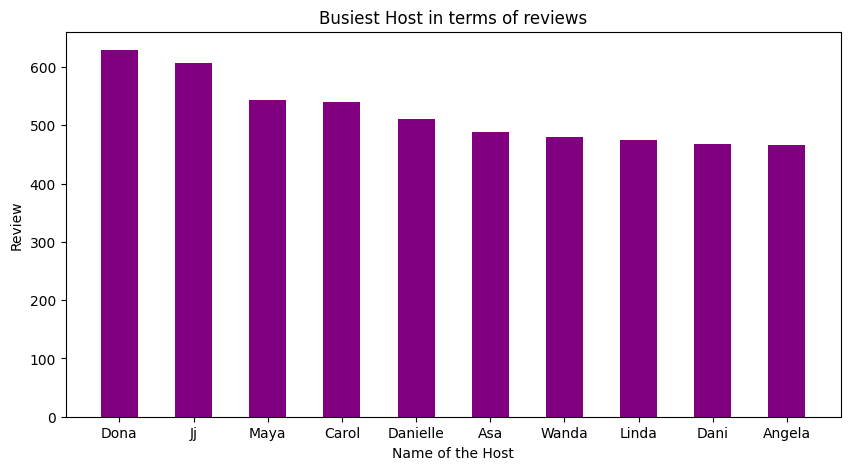

In [ ]:
name_hosts = busy_hosts['host_name']
review_got = busy_hosts['number_of_reviews']

fig = plt.figure(figsize =(10,5))

plt.bar(name_hosts,review_got, color ='purple', width =0.5)
plt.xlabel('Name of the Host')
plt.ylabel('Review')
plt.title("Busiest Host in terms of reviews")
plt.show()

Finding: Top hosts (Dona, Ji, Maya, Carol, Danielle) offer entire homes and private rooms with high review counts.

Insight: Room type choice directly impacts competitiveness—entire/private rooms succeed; shared rooms struggle.

Business Action: Learn from top hosts' strategy; avoid shared-room-only portfolios.

####CHART - 7 Average Price by Room Type & Neighbourhood

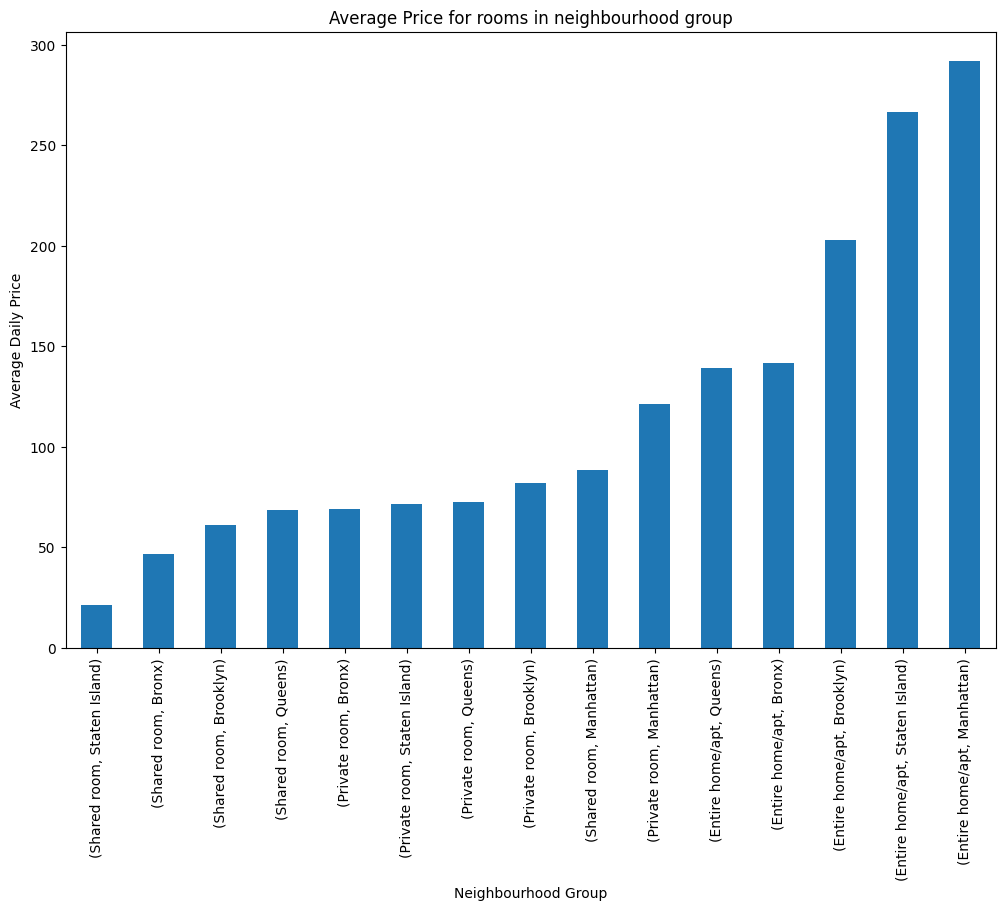

List of Average Price per night based on the neighbourhood group


price
room_type       neighbourhood_group            
Entire home/apt Queens               139.036260
                Bronx                141.541176
                Brooklyn             202.895245
                Staten Island        266.205128
                Manhattan            291.784595
Private room    Bronx                 69.025862
                Staten Island         71.394366
                Queens                72.454958
                Brooklyn              81.713284
                Manhattan            121.434183
Shared room     Staten Island         21.000000
                Bronx                 46.711111
                Brooklyn              60.921212
                Queens                68.459459
                Manhattan             88.462898

In [ ]:
# Chart - 7 visualization code
airbnb.head()

plt.figure(figsize=(12,8))
df = airbnb[airbnb['minimum_nights']==1]
df1 = df.groupby(['room_type','neighbourhood_group'])['price'].mean().sort_values(ascending=True)
df1.plot(kind='bar')
plt.title('Average Price for rooms in neighbourhood group')
plt.ylabel('Average Daily Price')
plt.xlabel('Neighbourhood Group')
plt.show()
print('List of Average Price per night based on the neighbourhood group')
pd.DataFrame(df1).sort_values(by='room_type')


Finding: Average daily prices vary significantly across neighbourhoods; entire homes command 2-3x premium over shared rooms.

Insight: Market clearly values privacy and autonomy in pricing structure.

Business Action: Price entire homes accordingly; shared rooms require aggressive discounting or premium features.

####CHART - 8  Hosts by Review Count

In [ ]:
# Chart - 8 visualization code
#Get the host based on number of reviews
host_based_on_review_df = airbnb.groupby(['host_id','host_name'],as_index=False)['number_of_reviews'].sum().sort_values(['number_of_reviews'],ascending = False)
host_based_on_review_df

,host_id,host_name,number_of_reviews
21316,37312959,Maya,2273
1052,344035,Brooklyn& Breakfast -Len-,2205
18636,26432133,Danielle,2017
20884,35524316,Yasu & Akiko,1971
21934,40176101,Brady,1818
...,...,...,...
37416,273524881,Shannon,0
37449,274188386,Qizhi,0
37448,274103383,Jennifer,0
37447,274079964,Richard,0


In [ ]:
#Get the host based on availability in a year
host_based_on_availability_df = airbnb.groupby(['host_id','host_name'],as_index=False)['availability_365'].mean().sort_values(['availability_365'],ascending = True)
host_based_on_availability_df

,host_id,host_name,availability_365
10649,8862886,Rachel,0.0
27203,76537707,Angela,0.0
27248,77076962,Meghan,0.0
10609,8813443,Win,0.0
10612,8816087,Danilo,0.0
...,...,...,...
15137,17550546,Genevieve,365.0
15169,17618198,Edvaldo,365.0
15202,17696653,Arleta,365.0
23,7355,Vt,365.0


In [ ]:
# Merge host performance data based on reviews and availability
popular_host_df = pd.merge(host_based_on_review_df, host_based_on_availability_df, on=['host_id', 'host_name'], how='inner')
# Rename columns for clarity in plotting
popular_host_df = popular_host_df.rename(columns={'number_of_reviews': 'Number of reviews', 'availability_365': 'Availability in a year'})


In [ ]:
#Most popular top 5 host in new york
popular_host_df.head(5)

,host_id,host_name,Number of reviews,Availability in a year
0,37312959,Maya,2273,164.800000
1,344035,Brooklyn& Breakfast -Len-,2205,286.384615
2,26432133,Danielle,2017,288.600000
3,35524316,Yasu & Akiko,1971,232.636364
4,40176101,Brady,1818,48.857143


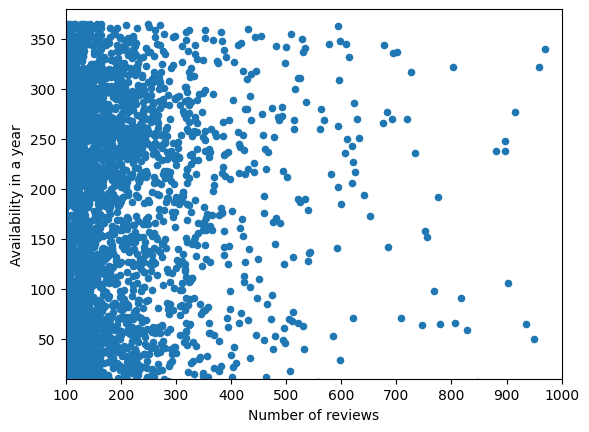

In [ ]:
#Create scatter plot based on number of reviews and availability in a year

popular_host_df.plot.scatter(x='Number of reviews', y='Availability in a year', xlim=(100,1000),ylim=(10,380));

Finding: Top hosts accumulate hundreds of reviews through consistent, quality offerings.
Insight: Review volume correlates with trustworthiness and repeat bookings.
Business Action: Focus on guest satisfaction to build review history.

####CHART-9

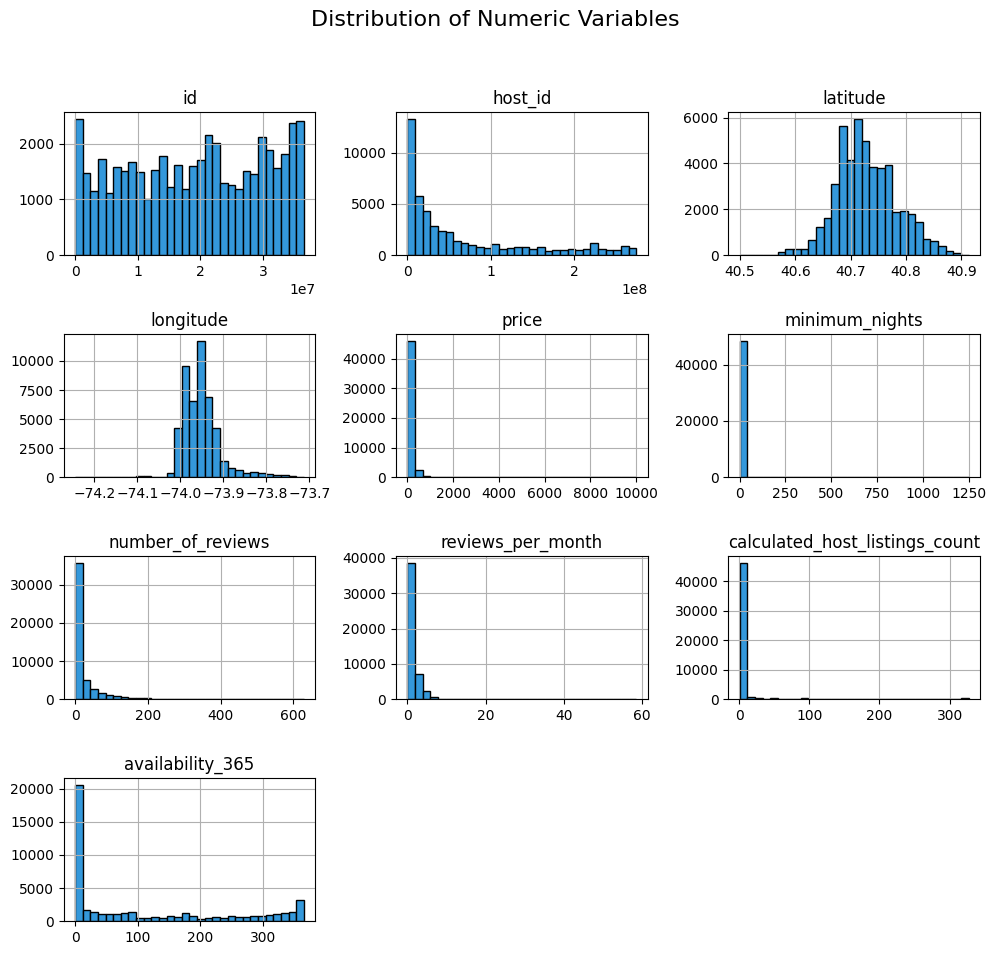

In [ ]:
# Chart - 9 visualization code
# This creates a grid of histograms for all numeric columns in the dataset
airbnb.hist(figsize=(10,10), bins=30, color='#3498db', edgecolor='black')

# Add a main title to the figure
plt.suptitle('Distribution of Numeric Variables', fontsize=16)

# Use tight_layout to ensure labels don't overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# FIX: Added parentheses to properly call the show function
plt.show()

Finding: Outliers present in price, availability, and review columns.

Insight: Some listings are extreme outliers (prices $10,000+, availability extremes); these distort market analysis.

Business Action: Monitor outliers separately; don't let premium luxury listings skew your pricing strategy.

####CHART -10 Detailed Price Distribution (Boxenplot)

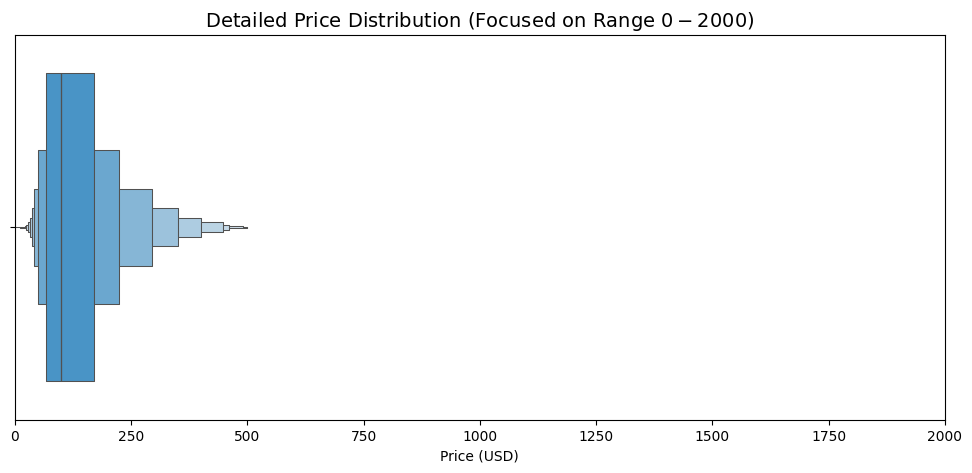

In [ ]:
# Chart - 10 visualization code
plt.figure(figsize=(12, 5))

# Create the boxenplot
# We use a color to make the distribution levels clearer
sns.boxenplot(x='price', data=airbnb, color='#3498db')

# FIX: Set a limit on the x-axis to make the main price distribution visible
# Most data is under 2000; this prevents the 10000 outliers from squishing the plot
plt.xlim(0, 2000)

# Add descriptive labels
plt.title('Detailed Price Distribution (Focused on Range $0 - $2000)', fontsize=14)
plt.xlabel('Price (USD)')

plt.show()

Finding: Most listings priced below $2,000; clear concentration under $500.

Insight: Price clustering reveals the sweet spot for NYC Airbnb market.

Business Action: Position pricing within $100-500 range for mainstream appeal.

####CHART -11 Total Listings by Neighbourhood Group

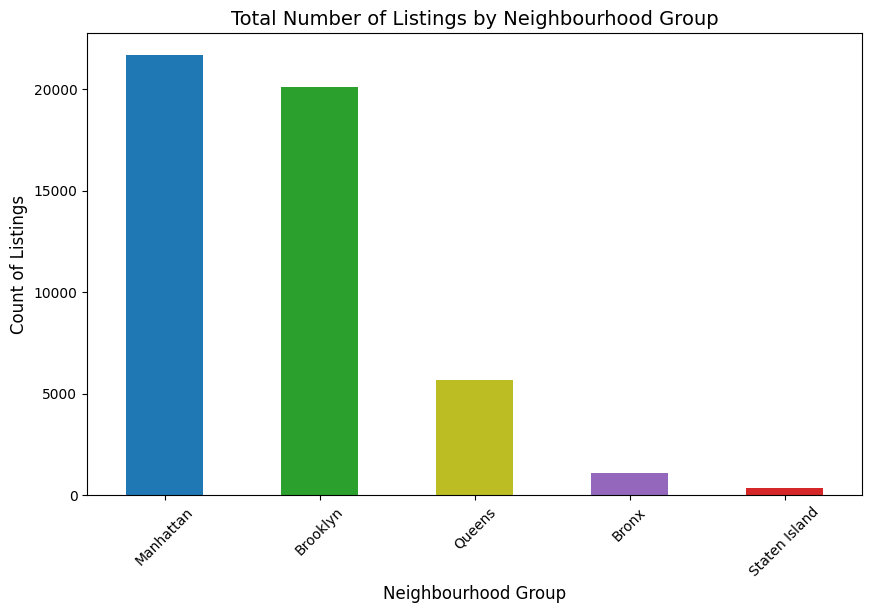

In [ ]:

# This bar chart shows the total number of listings in each borough (Neighbourhood Group)
plt.figure(figsize=(10, 6))

# We use value_counts() to get the frequency and plot it as a bar chart
airbnb['neighbourhood_group'].value_counts().plot(
    kind='bar',
    color=['#1f77b4', '#2ca02c', '#bcbd22', '#9467bd', '#d62728'] # Using hex versions of b, g, y, m, r for a cleaner look
)

# Adding labels and title for better readability
plt.title('Total Number of Listings by Neighbourhood Group', fontsize=14)
plt.xlabel('Neighbourhood Group', fontsize=12)
plt.ylabel('Count of Listings', fontsize=12)

# Rotating the x-axis labels to make them easy to read
plt.xticks(rotation=45)

# Display the plot
plt.show()

Finding: Manhattan and Brooklyn have majority of listings; Queens, Bronx, and Staten Island are underrepresented.

Insight: Market saturation in major boroughs; less competition in outer areas.

Business Action: Consider untapped markets in outer boroughs for lower competition.

####CHART-12 Top 10 Hosts by Listing Count

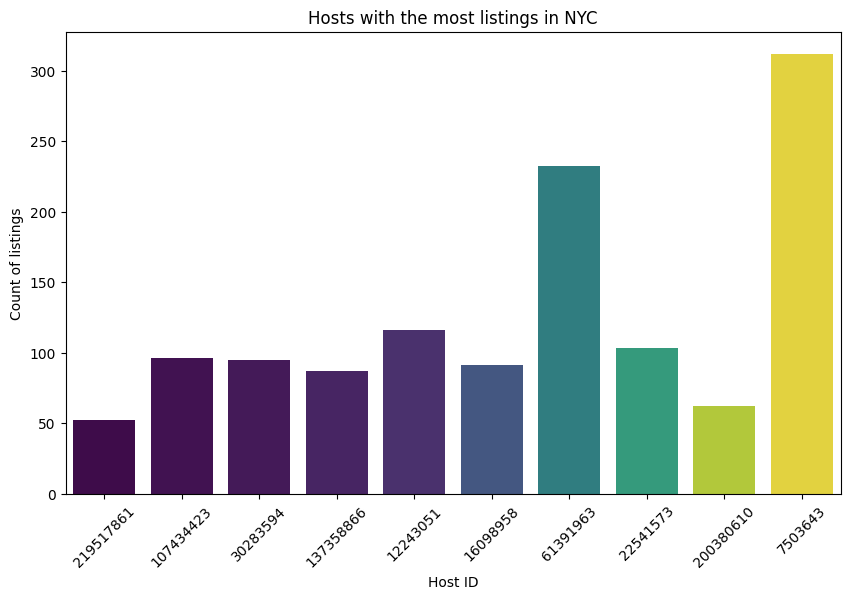

In [ ]:
# Chart - 12 visualization code

# 1. Get the top 10 hosts
top_host = airbnb.host_id.value_counts().head(10)

# 2. Convert to DataFrame and reset index
top_host_df = top_host.reset_index()

# 3. Standardize column names
top_host_df.columns = ['Host_ID', 'P_Count']

# 4. Visualization
plt.figure(figsize=(10, 6))

viz_1 = sns.barplot(
    x="Host_ID",
    y="P_Count",
    data=top_host_df,
    hue="Host_ID",
    palette='viridis',
    legend=False
)

# 5. Formatting & Fixing the Warning
viz_1.set_title('Hosts with the most listings in NYC')
viz_1.set_ylabel('Count of listings')
viz_1.set_xlabel('Host ID')

# FIX: Set the tick positions first, then the labels
viz_1.set_xticks(range(len(top_host_df)))
viz_1.set_xticklabels(top_host_df['Host_ID'], rotation=45)

plt.show()

Finding: A small number of hosts own a significant portion of the total Airbnb listings in NYC.

Insight: The market shows high concentration, with a few super-hosts dominating inventory. This indicates successful scaling strategies by these hosts.

Business Action: Analyze the strategies of these top hosts (e.g., pricing, property types, service quality) to identify best practices for growth and market penetration.

####CHART-13

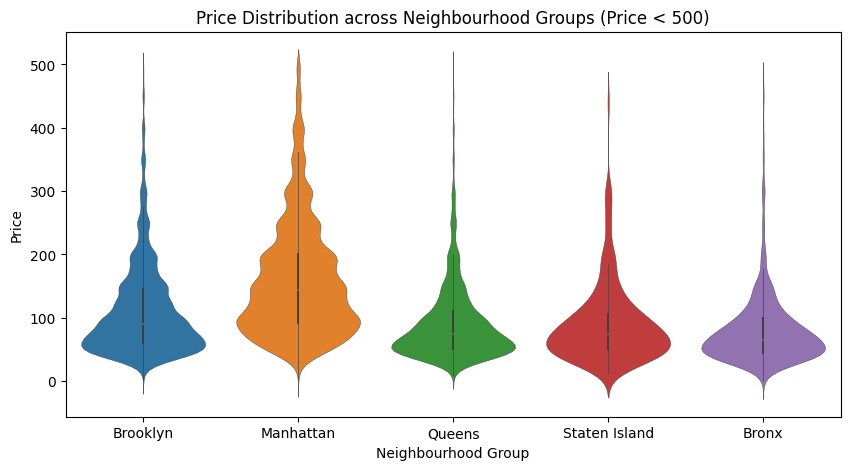

In [ ]:
# Chart - 13 visualization code
# 1. Filter the dataset to exclude extreme outliers for better visualization
airbnb = airbnb[airbnb['price'] < 500]

# 2. Set up the figure size
plt.figure(figsize=(10, 5))

# 3. Create the violin plot
# FIX: 'scale' is renamed to 'density_norm'
# Added 'hue' and 'legend=False' to satisfy new Seaborn requirements
sns.violinplot(
    x='neighbourhood_group',
    y='price',
    data=airbnb,
    hue='neighbourhood_group',
    density_norm='count',
    linewidth=0.3,
    legend=False
)

# 4. Add labels and title
plt.title('Price Distribution across Neighbourhood Groups (Price < 500)')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Price')

# 5. Display the plot
plt.show()

In [ ]:
# This cell was originally used for price filtering, which has been moved to an earlier stage for data consistency.
# Therefore, this cell is now empty to avoid redundant or misplaced operations.

A violin plot is a hybrid of a box plot and a kernel density plot, which shows peaks in the data.
the adjacent violin plot represnts the price distribution across the neighbourhood groups.

Finding: Manhattan exhibits the highest price range and is the most expensive neighborhood group, with Brooklyn having a high, but comparatively cheaper, price range. Queens, Bronx, and Staten Island offer narrower and generally cheaper options.

Insight: The market clearly segments by borough, with premium pricing concentrated in Manhattan and Brooklyn, while outer boroughs cater to more budget-conscious travelers.

Business Action: Tailor pricing and marketing strategies to the specific neighbourhood group; aggressively price listings in outer boroughs to attract demand, or focus on premium offerings in Manhattan and Brooklyn.

#### CHART -14

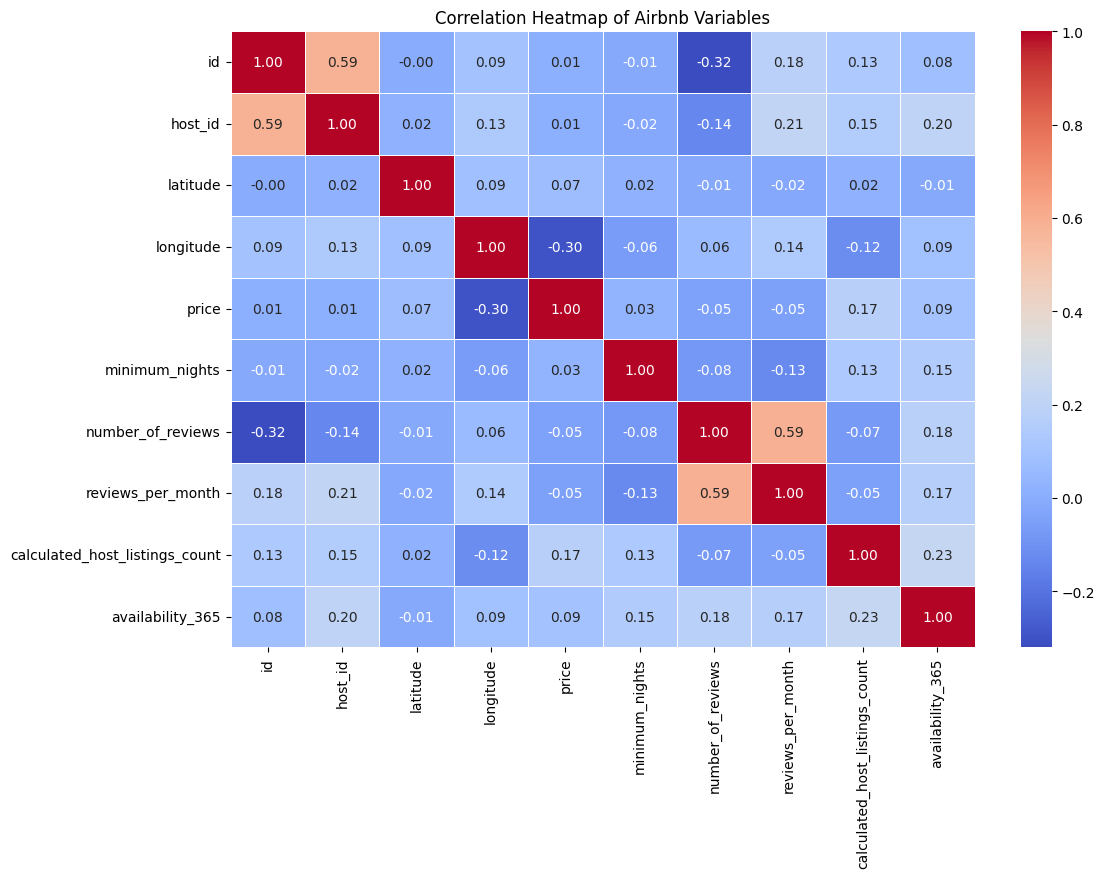

In [ ]:
# Chart - 14 visualization code
plt.figure(figsize=(12, 8))

# FIX: Use .select_dtypes(include=['number']) to filter out text columns
# This prevents the ValueError: could not convert string to float
numeric_airbnb = airbnb.select_dtypes(include=['number'])
correlation_matrix = numeric_airbnb.corr()

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")

plt.title('Correlation Heatmap of Airbnb Variables')
plt.show()

Finding: The heatmap illustrates the strength and direction of linear relationships between numeric variables in the dataset.

Insight: Strong positive or negative correlations (e.g., between `number_of_reviews` and `reviews_per_month`) highlight interdependent metrics. Weak correlations suggest independent variables or non-linear relationships.

Business Action: Use strongly correlated variables to inform predictions (e.g., more reviews usually mean higher reviews per month). Explore variables with weak correlations further to uncover non-linear patterns or remove redundant features.

####CHART-15

<Figure size 1500x1200 with 0 Axes>

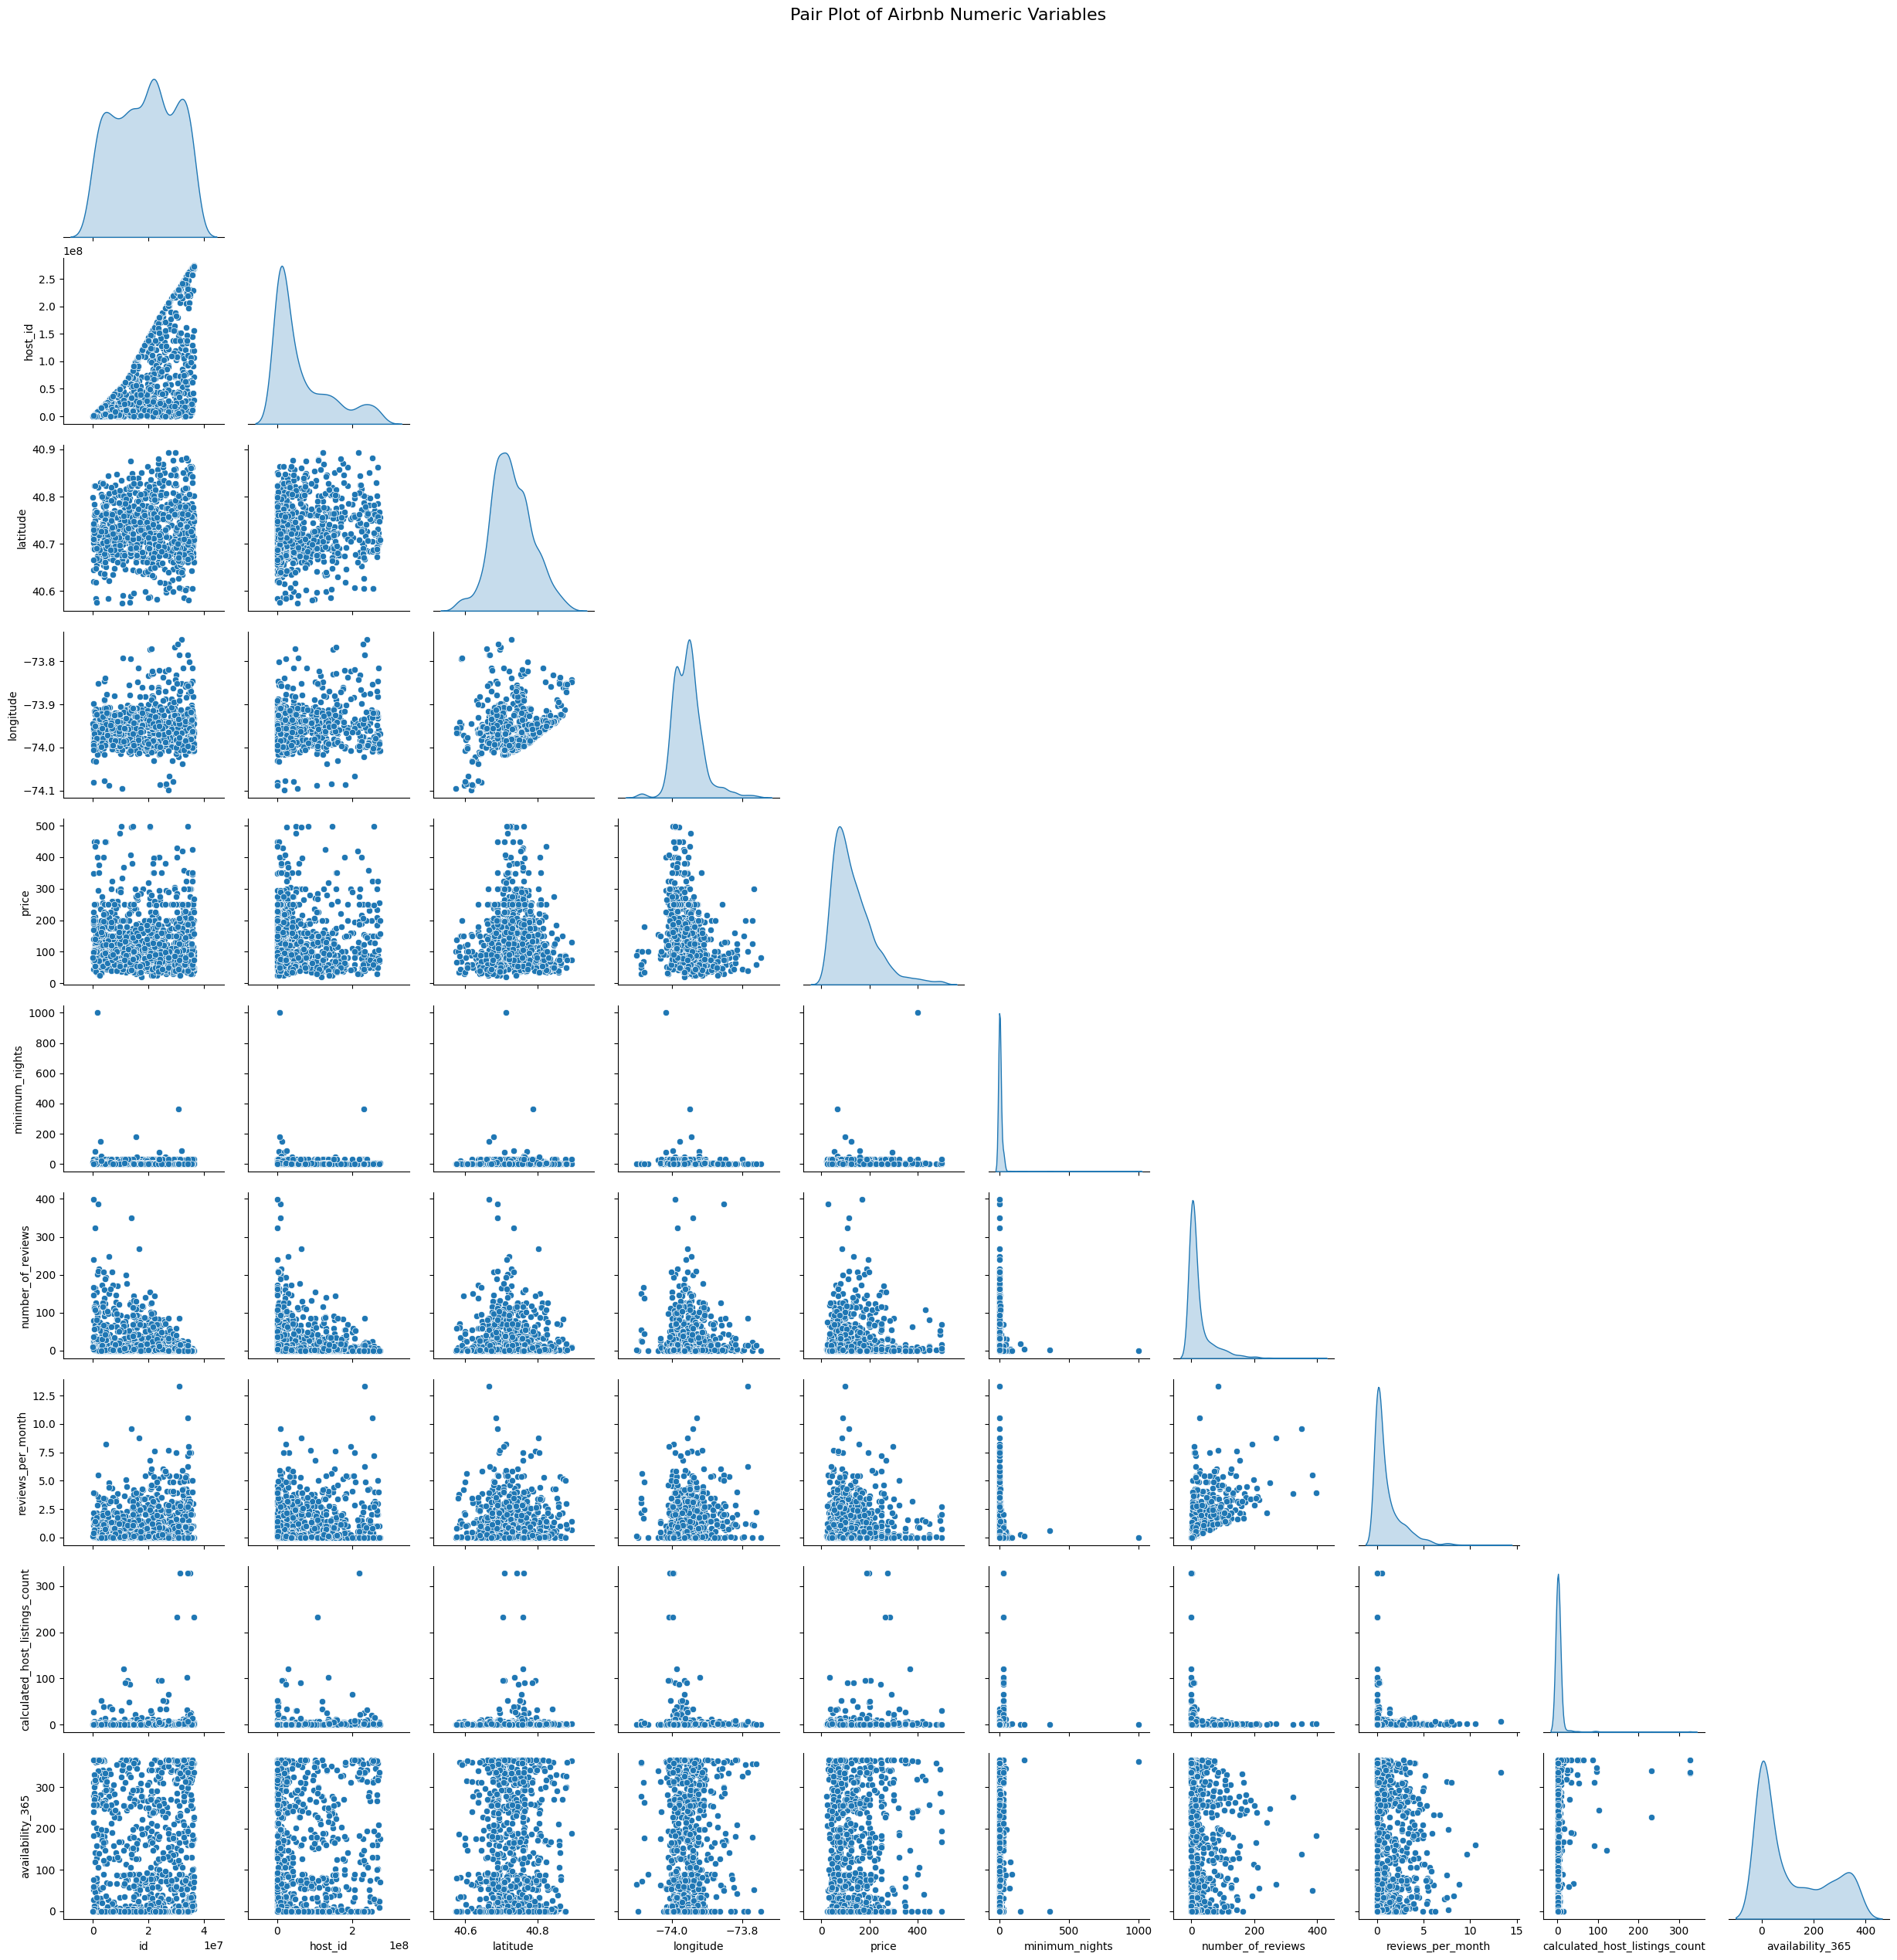

In [ ]:
# Pair Plot visualization code
# 1. Select only numeric columns to avoid errors with text/dates
numeric_cols = airbnb.select_dtypes(include=['number'])

# 2. We use a sample (e.g., 1000 rows) so the chart renders quickly
# and doesn't crash your Google Colab session.
sampled_data = numeric_cols.sample(n=min(1000, len(numeric_cols)), random_state=42)

# 3. Create the Pair Plot using Seaborn
plt.figure(figsize=(15, 12))
pair_plot = sns.pairplot(sampled_data, diag_kind='kde', corner=True)

# 4. Add a title
plt.suptitle('Pair Plot of Airbnb Numeric Variables', y=1.02, fontsize=16)

plt.show()

Finding: The pair plot effectively visualizes the relationships and distributions of various numeric variables, revealing potential correlations and the presence of outliers.

Insight: This comprehensive view helps in identifying patterns between features, understanding their individual distributions (e.g., skewness, presence of multiple modes), and detecting data anomalies or extreme values that might require further investigation or preprocessing.

Business Action: Use insights from variable relationships to guide feature engineering for predictive models. Address identified outliers to improve model robustness and ensure more accurate analyses. Focus on variables showing clear trends or clusters for deeper segment-specific strategies.

## Project Conclusion

This project analyzed the Airbnb New York City 2019 dataset to uncover key trends and insights relevant to hosts, guests, and the platform itself. Through a series of visualizations and data wrangling, we identified several critical aspects of the market:

**1. Market Concentration & Pricing Dynamics:**
*   **Geographic Distribution:** Manhattan and Brooklyn dominate the listing landscape, indicating high demand and market saturation in these areas. Queens, Bronx, and Staten Island represent untapped potential with less competition.
*   **Room Type Preferences:** 'Entire home/apt' is the most preferred room type, followed by 'Private room', commanding significantly higher prices (2-3x premium) than 'Shared room'. This highlights a strong market preference for privacy and autonomy.
*   **Price Distribution:** Most listings are priced below \$2,000, with a clear concentration under \$500, suggesting this is the 'sweet spot' for mainstream appeal. Outliers with prices up to \$10,000 exist, often for entire homes in premium locations, but these distort general market analysis.

**2. Host Performance & Guest Engagement:**
*   **Top Hosts:** A small number of 'super-hosts' dominate the market, holding a large number of listings. Analyzing their strategies (e.g., room types offered, pricing, guest satisfaction) can provide best practices for growth.
*   **Review Impact:** Reviews play a crucial role in host success. Rooms priced below \$500 tend to receive the most reviews, indicating higher guest engagement and price sensitivity. Top hosts accumulate hundreds of reviews through consistent, quality offerings, correlating with trustworthiness and repeat bookings.

**3. Data Quality & Next Steps:**
*   **Missing Values:** Initial data cleaning addressed missing values in `name`, `host_name`, `last_review`, and `reviews_per_month` by filling them with meaningful substitutes ('No Name', 'Unknown', 'Not Reviewed', 0 respectively).
*   **Outliers:** Several numeric variables (e.g., `price`, `availability_365`, `number_of_reviews`) contain significant outliers. These need careful consideration in further analyses, potentially requiring separate monitoring or advanced outlier handling techniques to avoid skewing predictive models.
*   **Correlations:** A correlation heatmap revealed relationships between numeric variables, such as a strong positive correlation between `number_of_reviews` and `reviews_per_month`, which can inform feature engineering.

**Business Actions & Recommendations:**
*   **Strategic Pricing:** Differentiate pricing by borough and room type. Position mainstream listings within the \$100-500 range. For entire homes in Manhattan/Brooklyn, price aggressively. For shared rooms, consider aggressive discounting or adding premium features to compete.
*   **Market Expansion:** Explore underserved boroughs (Queens, Bronx, Staten Island) for lower competition and new business opportunities.
*   **Guest Satisfaction:** Prioritize guest satisfaction to build a strong review history, especially for listings under \$500. Learn from the strategies of top-performing hosts.
*   **Data Refinement:** For future predictive modeling, address outliers in price and availability carefully. Further explore non-linear relationships or independent variables revealed by weak correlations.